# Dataset Generation

This notebook is for generating our initial dataset, we may or may not add additional variables later in our pipeline

## Dataset Description

### Target Dataset:

Near-surface air temperature data in an index format was collected on 24 July 2021 across the Bronx and Manhattan regions of New York City in the United States. The data was collected in the afternoon between 3:00 pm and 4:00 pm. This dataset includes time stamps, traverse points (latitude and longitude) and the corresponding Urban Heat Island (UHI) Index values for 11229 data points. These UHI Index values are the target parameters for our models.

- UHI Index = (Temperature at a given location) / (Mean
temperature for all locations)

The chosen UHI index serves as a crucial metric for
assessing the intensity of heat within different urban
zones of the city. For comparison, most literature
calculates a UHI index based on temperature
differences between inner city locations and rural
locations far outside of the city. Since we did not have
data from rural locations, we created a unique UHI
index that reflects the variability of temperatures
within our collected dataset and time collection
window. As an example, a UHI index value of 1.0
suggests the local temperature is the same as the
mean temperature of all collected data points. UHI
index values above 1.0 are consistent with hotspots
above mean temperature values and UHI index values
below 1.0 are consistent with cooler locations in the
city.




> **!!!Note!!!**: Participants are strictly prohibited from using Longitude and Latitude values as features in building their machine learning models. These values should only be utilized for understanding the attributes and characteristics of the locations.

![UHI Collection Route](https://github.com/FranciscoLozCoding/cooling_with_code/blob/main/images/UHI_route.jpeg?raw=1)
>The image above shows the collection route. It also shows areas of
lower UHI index values (cool spots) in yellow and areas of higher
UHI index values (hot spots) in dark red.

### Feature Datasets:

- European Sentinel-2 optical satellite data
- NASA Landsat optical satellite data
- Building footprints of the Bronx and Manhattan regions
- Detailed local weather dataset of the Bronx and Manhattan regions on 24 July 2021

## Combining The Data

### Set Up

Download libraries not in google collab (can be disregarded if not using collab)

In [2]:
%pip install stackstac
%pip install pystac-client
%pip install planetary-computer
%pip install odc-stac
%pip install rioxarray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.3/64.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 73.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.2/194.2 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.4/89.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.8/153.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 1.6 MB/s eta 0:00:00


Import libraries

In [3]:
# Supress Warnings
import warnings
warnings.filterwarnings('ignore')

# Import common GIS tools
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import rioxarray as rio
import rasterio
from matplotlib.cm import RdYlGn,jet,RdBu
from google.colab import drive
import geopandas as gpd
from shapely.geometry import Point, Polygon
from rasterio.mask import mask
from shapely.ops import transform
import pyproj
import shapely.vectorized
from geopy.distance import geodesic

# Import Planetary Computer tools
import stackstac
import pystac_client
import planetary_computer
from odc.stac import stac_load

#other libs
import pandas as pd
from tqdm import tqdm
from joblib import Parallel, delayed
from datetime import timedelta

Mount google drive, ignore if not using Google Collab:

In [4]:
# mount google drive
drive.mount('/content/drive')
%cd /content/drive/My Drive
!git clone https://github.com/FranciscoLozCoding/cooling_with_code.git
%cd cooling_with_code
!git pull

Mounted at /content/drive
/content/drive/My Drive
fatal: destination path 'cooling_with_code' already exists and is not an empty directory.
/content/drive/My Drive/cooling_with_code
remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 3 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 1.43 KiB | 0 bytes/s, done.
From https://github.com/FranciscoLozCoding/cooling_with_code
   82d407e..843202c  main       -> origin/main
Updating 82d407e..843202c
Fast-forward
 01_dataset_generation.ipynb | 43 +++++++++++++++++++++++++++++++------------
 1 file changed, 31 insertions(+), 12 deletions(-)


### Helper Functions

In [48]:
def load_building_footprints(kml_file):
    """
    Load building footprint polygons from a KML file.

    Parameters:
        kml_file (str): Path to the KML file.

    Returns:
        GeoDataFrame: A GeoDataFrame of building footprints in EPSG:4326.
    """
    buildings_gdf = gpd.read_file(kml_file, driver="KML")
    # Ensure the CRS is set correctly
    buildings_gdf = buildings_gdf.set_crs(epsg=4326)
    return buildings_gdf

In [59]:
def building_density_in_buffer(buffer_geom, buildings_gdf, metric_epsg=32618):
    """
    Calculate building density metrics within a buffer.

    Parameters:
        buffer_geom (shapely.geometry.Polygon): The buffer in EPSG:4326.
        buildings_gdf (GeoDataFrame): Building footprints in EPSG:4326.
        metric_epsg (int): EPSG code for a metric CRS (default is 32618 for New York).

    Returns:
        dict: Contains 'building_count', 'total_building_area' (m²), and 'density' (fraction of buffer area covered).
    """
    # Project both the buildings and buffer to a metric CRS.
    buildings_metric = buildings_gdf.to_crs(epsg=metric_epsg)
    buffer_metric = gpd.GeoSeries([buffer_geom], crs="EPSG:4326").to_crs(epsg=metric_epsg).iloc[0]

    # Compute the area of the buffer (in m²)
    buffer_area = buffer_metric.area

    # Select buildings that intersect the buffer.
    buildings_in_buffer = buildings_metric[buildings_metric.intersects(buffer_metric)]
    building_count = len(buildings_in_buffer)

    # For a more precise estimate, compute the intersection area of each building with the buffer.
    intersection_area = buildings_in_buffer.intersection(buffer_metric).area.sum()
    density = intersection_area / buffer_area if buffer_area > 0 else np.nan

    return {
        "building_count": building_count,
        "total_building_area_m2": intersection_area,
        "building_density": density
    }

In [5]:
def average_band_in_buffer(lat, lon, buffer_radius, xarray, band_name, project_to_utm, project_to_wgs84):
    """
    Calculate the average values of a given band within a circular buffer.

    Parameters:
        lat (float): Latitude of the center point (EPSG:4326).
        lon (float): Longitude of the center point (EPSG:4326).
        buffer_radius (float): Radius of the buffer in meters.
        xarray (xarray.DataArray or xarray.Dataset): Xarray object containing the band.
            It must have 1D coordinate arrays 'latitude' and 'longitude' in EPSG:4326.
        band_name (str): Name of the band to process (e.g., 'NDVI').
        project_to_utm (pyproj.Transformer): Transformer to project points to UTM.
        project_to_wgs84 (pyproj.Transformer): Transformer to project points back to WGS84.

    Returns:
        float: The average band value within the buffer. Returns NaN if no grid cells are found.
    """

    # Create a Shapely point (note: Shapely uses (lon, lat)).
    point = Point(lon, lat)

    # Project the point to UTM, create the buffer, then transform the buffer back to EPSG:4326.
    point_utm = transform(project_to_utm, point)
    buffer_utm = point_utm.buffer(buffer_radius)
    buffer_wgs84 = transform(project_to_wgs84, buffer_utm)

    # Extract coordinate arrays from the xarray data.
    # Assumes that the band is available in xarray[band_name]
    lons = xarray[band_name].coords['longitude'].values
    lats = xarray[band_name].coords['latitude'].values

    # Create a 2D meshgrid of longitude and latitude.
    lon_grid, lat_grid = np.meshgrid(lons, lats)

    # Create a boolean mask for grid cells that fall inside the buffer.
    mask = shapely.vectorized.contains(buffer_wgs84, lon_grid, lat_grid)

    # Extract the band values as a NumPy array.
    band_data = xarray[band_name].values

    # Compute the average of the band values inside the buffer.
    # np.nanmean ignores NaN values if they exist.
    if np.any(mask):
        average_val = np.nanmean(band_data[mask])
    else:
        average_val = np.nan  # or you could choose to raise an error if no cells are found

    return average_val

In [ ]:
#TODO: compare new and old generate dataset functions
def new_generate_index_dataset(latitudes, longitudes, datetimes, buffer_radius, median, buildings_gdf, epsg_code_for_meters="EPSG:32618"):
    '''
    Generate a dataset with averaged indices and building density metrics per buffer.

    Parameters:
        latitudes (list): Latitudes of center points (EPSG:4326).
        longitudes (list): Longitudes of center points (EPSG:4326).
        datetimes (list): Corresponding datetimes.
        buffer_radius (float): Buffer radius in meters.
        median (xarray.DataArray or Dataset): Contains the bands (e.g., 'NDVI', 'NDBI', etc.).
        buildings_gdf (GeoDataFrame): Building footprints (loaded from a KML file), in EPSG:4326.
        epsg_code_for_meters (str, optional): EPSG code for metric projection (e.g., "EPSG:32618" for New York).

    Returns:
        DataFrame: A DataFrame with indices averaged per buffer plus building density metrics.
    '''
    # Set up CRS and transformation functions.
    crs_wgs84 = pyproj.CRS("EPSG:4326")
    crs_utm = pyproj.CRS(epsg_code_for_meters)
    project_to_utm = pyproj.Transformer.from_crs(crs_wgs84, crs_utm, always_xy=True).transform
    project_to_wgs84 = pyproj.Transformer.from_crs(crs_utm, crs_wgs84, always_xy=True).transform

    # Helper function to process a single point.
    def process_point(lat, lon):
        # Create the buffer around the point.
        point = Point(lon, lat)
        point_utm = transform(project_to_utm, point)
        buffer_utm = point_utm.buffer(buffer_radius)
        buffer_wgs84 = transform(project_to_wgs84, buffer_utm)

        # Calculate spectral indices.
        ndvi_value  = average_band_in_buffer(lat, lon, buffer_radius, median, 'NDVI', project_to_utm, project_to_wgs84)
        ndbi_value  = average_band_in_buffer(lat, lon, buffer_radius, median, 'NDBI', project_to_utm, project_to_wgs84)
        ndwi_value  = average_band_in_buffer(lat, lon, buffer_radius, median, 'NDWI', project_to_utm, project_to_wgs84)
        si_value    = average_band_in_buffer(lat, lon, buffer_radius, median, 'SI', project_to_utm, project_to_wgs84)
        ndmi_value  = average_band_in_buffer(lat, lon, buffer_radius, median, 'NDMI', project_to_utm, project_to_wgs84)
        npcri_value = average_band_in_buffer(lat, lon, buffer_radius, median, 'NPCRI', project_to_utm, project_to_wgs84)
        ca_value    = average_band_in_buffer(lat, lon, buffer_radius, median, 'Coastal_Aerosol', project_to_utm, project_to_wgs84)

        # Calculate building density metrics using the same buffer.
        building_metrics = building_density_in_buffer(buffer_wgs84, buildings_gdf)

        # Return all results.
        return (ndvi_value, ndbi_value, ndwi_value, si_value, ndmi_value, npcri_value, ca_value,
                building_metrics["building_count"], building_metrics["total_building_area"], building_metrics["density"])

    # Process all points in parallel.
    results = Parallel(n_jobs=-1)(
        delayed(process_point)(lat, lon)
        for lat, lon in tqdm(zip(latitudes, longitudes), total=len(latitudes), desc="Processing points")
    )

    # Unpack results.
    (ndvi_values, ndbi_values, ndwi_values, si_values,
     ndmi_values, npcri_values, ca_values,
     building_counts, building_areas, building_densities) = zip(*results)

    # Build the DataFrame.
    df = pd.DataFrame({
        'Longitude': longitudes,
        'Latitude': latitudes,
        'datetime': datetimes,
        'NDVI': ndvi_values,
        'NDBI': ndbi_values,
        'NDWI': ndwi_values,
        'SI': si_values,
        'NDMI': ndmi_values,
        'NPCRI': npcri_values,
        'Coastal_Aerosol': ca_values,
        'Building_Count': building_counts,
        'Total_Building_Area_m2': building_areas,
        'Building_Density': building_densities
    })
    return df

In [6]:
def generate_index_dataset(latitudes, longitudes, UHI, datetimes, buffer_radius, xarray, epsg_code_for_meters="EPSG:32618"):
    '''
    Generate the dataset with the averaged indices.

    Parameters:
        latitudes (list): List of latitudes for the center point (EPSG:4326).
        longitudes (list): List of longitudes for the center point (EPSG:4326).
        UHI (list): List of UHI values.
        datetimes (list): List of datetimes.
        buffer_radius (float): Radius of the buffer in meters.
        xarray (xarray.DataArray or xarray.Dataset): Xarray object containing the bands.
            It must have 1D coordinate arrays 'latitude' and 'longitude' in EPSG:4326.
        epsg_code_for_meters (str, optional): EPSG code for the meters (e.g., EPSG:32618 for New York)

    Returns:
        DataFrame: The dataset with the indices averaged per buffer.
    '''
    # Define coordinate reference systems.
    crs_wgs84 = pyproj.CRS("EPSG:4326")
    crs_utm = pyproj.CRS(epsg_code_for_meters)

    # Create transformation functions.
    project_to_utm = pyproj.Transformer.from_crs(crs_wgs84, crs_utm, always_xy=True).transform
    project_to_wgs84 = pyproj.Transformer.from_crs(crs_utm, crs_wgs84, always_xy=True).transform

    # Define a helper function that computes all the indices for one point.
    def process_point(lat, lon):
        ndvi_value = average_band_in_buffer(lat, lon, buffer_radius, xarray, 'NDVI', project_to_utm, project_to_wgs84)
        ndbi_value = average_band_in_buffer(lat, lon, buffer_radius, xarray, 'NDBI', project_to_utm, project_to_wgs84)
        ndwi_value = average_band_in_buffer(lat, lon, buffer_radius, xarray, 'NDWI', project_to_utm, project_to_wgs84)
        si_value    = average_band_in_buffer(lat, lon, buffer_radius, xarray, 'SI', project_to_utm, project_to_wgs84)
        ndmi_value  = average_band_in_buffer(lat, lon, buffer_radius, xarray, 'NDMI', project_to_utm, project_to_wgs84)
        npcri_value = average_band_in_buffer(lat, lon, buffer_radius, xarray, 'NPCRI', project_to_utm, project_to_wgs84)
        ca_value    = average_band_in_buffer(lat, lon, buffer_radius, xarray, 'Coastal_Aerosol', project_to_utm, project_to_wgs84)
        return (ndvi_value, ndbi_value, ndwi_value, si_value, ndmi_value, npcri_value, ca_value)

    # Process all points in parallel. n_jobs=-1 uses all available CPUs.
    results = Parallel(n_jobs=-1)(
        delayed(process_point)(lat, lon)
        for lat, lon in tqdm(zip(latitudes, longitudes), total=len(latitudes), desc="Extracting average values")
    )

    # Unpack the results into separate lists.
    ndvi_values, ndbi_values, ndwi_values, si_values, ndmi_values, npcri_values, ca_values = zip(*results)

    # Create a DataFrame with the computed indices.
    # (Note: the 'UHI' column was referenced in your original code but not computed;
    # you can add it later or remove it from the DataFrame.)
    df = pd.DataFrame({
        'Longitude': longitudes,
        'Latitude': latitudes,
        'datetime': pd.to_datetime(datetimes),
        'UHI': UHI,
        'NDVI': ndvi_values,
        'NDBI': ndbi_values,
        'NDWI': ndwi_values,
        'SI': si_values,
        'NDMI': ndmi_values,
        'NPCRI': npcri_values,
        'Coastal_Aerosol': ca_values
    })
    return df

In [7]:
# Function to determine the nearest weather station (Bronx or Manhattan)
def assign_weather_station(lat, lon):
    '''
    Assign a county (Bronx or Manhattan) based on the closest weather station.

      Parameters:
        lat (float): Latitude of the point (EPSG:4326).
        lon (float): Longitude of the point (EPSG:4326).

      Returns:
        str: 'Bronx' or 'Manhattan' based on the closest weather station.
    '''
    # Define the coordinates for Bronx and Manhattan
    bronx_coords = (40.87248, -73.89352)  # Bronx: (Latitude, Longitude)
    manhattan_coords = (40.76754, -73.96449)  # Manhattan: (Latitude, Longitude)

    # Calculate distance to Bronx and Manhattan using geopy's geodesic function
    distance_bronx = geodesic((lat, lon), bronx_coords).meters
    distance_manhattan = geodesic((lat, lon), manhattan_coords).meters

    # Assign the county based on the shortest distance
    if distance_bronx < distance_manhattan:
        return 'Bronx'
    else:
        return 'Manhattan'

In [8]:
# Function to find the closest datetime in the weather data
def find_closest_datetime(row, weather_data):
    '''
    Find the closest datetime in the weather data to the given row's datetime.

    Parameters:
        row (pd.Series): A row from a DataFrame containing a 'datetime' column.
        weather_data (pd.DataFrame): A DataFrame containing the weather data with a 'Date / Time' column.

    Returns:
        pd.Series: The row from weather_data with the closest datetime.
    '''
    # Calculate the absolute time difference between the row's datetime and each weather datetime
    time_diff = abs(weather_data['Date / Time'] - row['datetime'])

    # Find the index of the minimum time difference (closest datetime)
    closest_idx = time_diff.idxmin()

    # Return the row with the closest datetime
    return weather_data.iloc[closest_idx]

In [9]:
# Function to assign weather data based on county and closest datetime
def assign_weather_data(row, weather_manhattan, weather_bronx):
    '''
      Assign weather data based on the county and closest datetime.

      Parameters:
        row (pd.Series): A row from a DataFrame containing 'Latitude' and 'Longitude' columns.
        weather_manhattan (pd.DataFrame): A DataFrame containing weather data for Manhattan.
        weather_bronx (pd.DataFrame): A DataFrame containing weather data for Bronx.

      Returns:
        pd.Series: A row with the closest weather data
    '''
    # Determine which county the row belongs to
    county = assign_weather_station(row['Latitude'], row['Longitude'])

    # Find the closest weather data based on county
    if county == 'Manhattan':
        closest_weather = find_closest_datetime(row, weather_manhattan)
    elif county == 'Bronx':
        closest_weather = find_closest_datetime(row, weather_bronx)
    else:
        # Handle the case where the county is not recognized
        raise ValueError(f"Unknown county: {county}")

    # Return the weather data to merge
    return pd.Series({
        'Air Temp at Surface [degC]': closest_weather['Air Temp at Surface [degC]'],
        'Relative Humidity [percent]': closest_weather['Relative Humidity [percent]'],
        'Avg Wind Speed [m/s]': closest_weather['Avg Wind Speed [m/s]'],
        'Wind Direction [degrees]': closest_weather['Wind Direction [degrees]'],
        'Solar Flux [W/m^2]': closest_weather['Solar Flux [W/m^2]']
    })

### Discover and load the data for analysis

In [10]:
# Define the bounding box for the entire data region using (Latitude, Longitude)
# This is the region of New York City that contains our temperature dataset
lower_left = (40.75, -74.01)
upper_right = (40.88, -73.86)

In [11]:
# Calculate the bounds for doing an archive data search
# bounds = (min_lon, min_lat, max_lon, max_lat)
bounds = (lower_left[1], lower_left[0], upper_right[1], upper_right[0])

In [12]:
# Define the time window
time_window = "2021-06-01/2021-09-01"

>NOTE: we don't have to match the time window the target variable (UHI) was collected since the features that will be generated using the satellite images don't really change much in a small time window within the same season

Using the `pystac_client` we can search the Planetary Computer's STAC endpoint for items matching our query parameters. We will use a period of 3 months as a representative dataset for the region. The query searches for "low cloud" scenes with overall cloud cover <20%. The result is the number of scenes matching our search criteria that touch our area of interest. Some of these may be partial scenes or contain clouds.

In [13]:
stac = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")

search = stac.search(
    bbox=bounds,
    datetime=time_window,
    collections=["sentinel-2-l2a"],
    query={"eo:cloud_cover": {"lt": 20}},
)

In [14]:
items = list(search.get_items())
print('This is the number of scenes that touch our region:',len(items))

This is the number of scenes that touch our region: 7


Next, we'll load the data into an [xarray](https://xarray.pydata.org/en/stable/) DataArray using [stackstac](https://stackstac.readthedocs.io/). We will only keep the commonly used spectral bands (Red, Green, Blue, NIR, SWIR). There are also several other <b>important settings for the data</b>: We have changed the projection to epsg=4326 which is standard latitude-longitude in degrees. We have specified the spatial resolution of each pixel to be 10-meters.

In [15]:
signed_items = [planetary_computer.sign(item).to_dict() for item in items]

In [16]:
# Define the pixel resolution for the final product
# Define the scale according to our selected crs, so we will use degrees
resolution = 5  # meters per pixel
scale = resolution / 111320.0 # degrees per pixel for crs=4326

### Sentinel-2 Bands Summary
The following list of common bands can be loaded by the Open Data Cube (ODC) stac command.<br><br>
B01 = Coastal Aerosol = 60m <br>
B02 = Blue = 10m <br>
B03 = Green = 10m <br>
B04 = Red = 10m <br>
B05 = Red Edge (704 nm) = 20m <br>
B06 = Red Edge (740 nm) = 20m <br>
B07 = Red Edge (780 nm) = 20m <br>
B08 = NIR (833 nm) = 10m <br>
B8A = NIR (narrow 864 nm) = 20m <br>
B11 = SWIR (1.6 um) = 20m <br>
B12 = SWIR (2.2 um) = 20m

In [17]:
data = stac_load(
    items,
    bands=["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12"],
    crs="EPSG:4326", # Latitude-Longitude
    resolution=scale, # Degrees
    chunks={"x": 2048, "y": 2048},
    dtype="uint16",
    patch_url=planetary_computer.sign,
    bbox=bounds
)

In [18]:
# View the dimensions of our XARRAY and the loaded variables
# This insures we have the right coordinates and spectral bands in our xarray
display(data)

<xarray.Dataset> Size: 1GB
Dimensions:      (latitude: 2895, longitude: 3340, time: 7)
Coordinates:
  * latitude     (latitude) float64 23kB 40.88 40.88 40.88 ... 40.75 40.75 40.75
  * longitude    (longitude) float64 27kB -74.01 -74.01 -74.01 ... -73.86 -73.86
    spatial_ref  int32 4B 4326
  * time         (time) datetime64[ns] 56B 2021-06-06T15:38:09.024000 ... 202...
Data variables:
    B01          (time, latitude, longitude) uint16 135MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    B02          (time, latitude, longitude) uint16 135MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    B03          (time, latitude, longitude) uint16 135MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    B04          (time, latitude, longitude) uint16 135MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    B05          (time, latitude, longitude) uint16 135MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    B06          (time, latitude, longitude) uint16 135MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    B07          (time, latitude, longitude) uint16 135MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    B08          (time, latitude, longitude) uint16 135MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    B8A          (time, latitude, longitude) uint16 135MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    B11          (time, latitude, longitude) uint16 135MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    B12          (time, latitude, longitude) uint16 135MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>

### View RGB (real color) images from the time series
Some of the scenes have clouds. We may want to use a scene from a single date, or create a median composite using all of the data in the time series. Also, these images are merely for quick review and are not scaled correctly to reflect the proper Lat-Lon ratios. Finally, the numbering for these scenes starts at ZERO and goes from the top-left across the rows to reach the total number of scenes in the data array shown above.

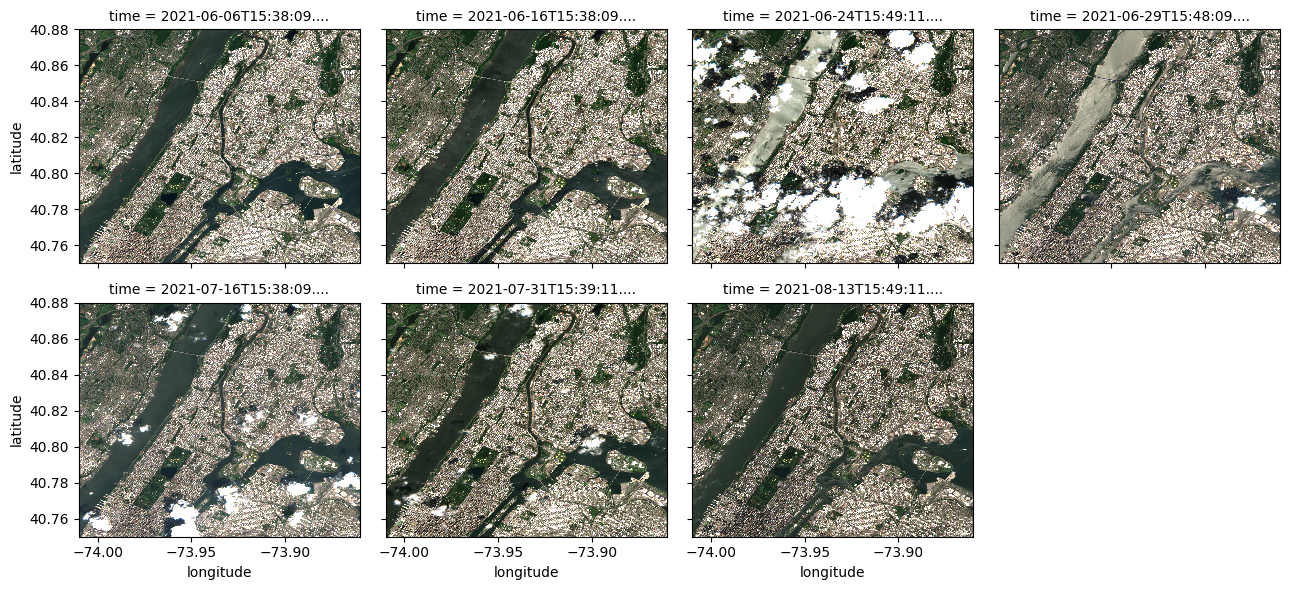

In [19]:
# Plot sample images from the time series
plot_data = data[["B04","B03","B02"]].to_array()
plot_data.plot.imshow(col='time', col_wrap=4, robust=True, vmin=0, vmax=2500)
plt.show()

### Median composite

Using normal xarray operations, we can [compute the median](http://xarray.pydata.org/en/stable/generated/xarray.DataArray.median.html) over the time dimension. Under the assumption that clouds are not common (<20% per scene) and in random locations, the composite shouldn't contain (many) clouds, since they shouldn't be the median pixel value at that point over many images.

In [20]:
median = data.median(dim="time").compute()

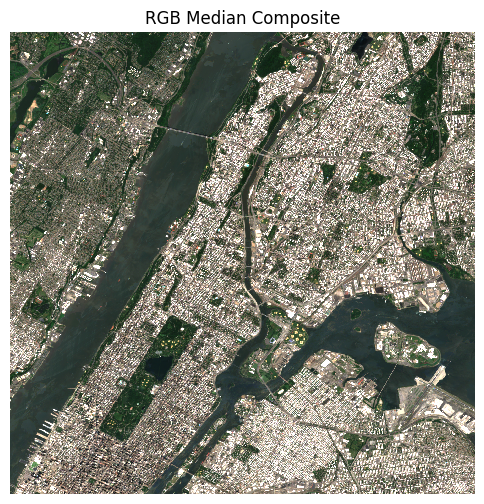

In [21]:
# Plot an RGB image for the median composite
# This new image is void of clouds due to statistical filtering
fig, ax = plt.subplots(figsize=(6,6))
median[["B04", "B03", "B02"]].to_array().plot.imshow(robust=True, ax=ax, vmin=0, vmax=2500)
ax.set_title("RGB Median Composite")
ax.axis('off')
plt.show()

### Creating The Index Variables

First, we will create index variables based on the bands from the satellites.

#### Normalized Difference Vegetation Index (NDVI)

The <b>Normalized Difference Vegetation Index (NDVI)</b> is used to measure the "greenness" of vegetation and has a range of 0.0 to 1.0. Low values (0.0 to 0.25) reflect a lack of vegetation (bare soil, urban, water), middle values (0.25 to 0.6) reflect grasslands or croplands in their growing state, and high values (0.6 to 1.0) reflect dense vegetation such as trees or croplands at their peak vegetation state. Such information can be relevant to modeling urban heating as the proximity to vegetation or "green space" can mitigate urban heating. The equation uses two spectral bands where: <b>NDVI = (NIR-Red) / (NIR+Red).

In [22]:
# Calculate NDVI for the median composite
ndvi_median = (median.B08-median.B04)/(median.B08+median.B04)

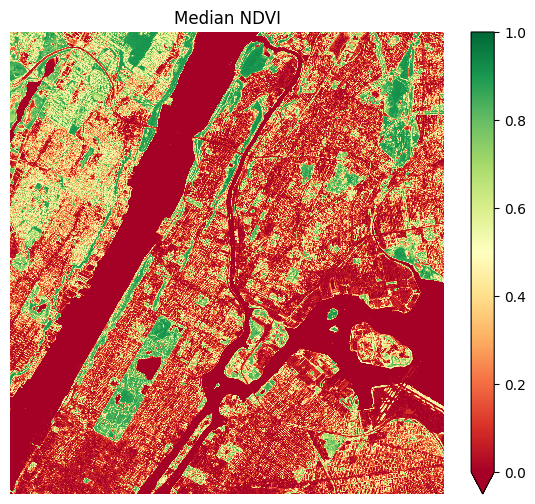

In [23]:
fig, ax = plt.subplots(figsize=(7,6))
ndvi_median.plot.imshow(vmin=0.0, vmax=1.0, cmap="RdYlGn")
plt.title("Median NDVI")
plt.axis('off')
plt.show()

#### Normalized Difference Buildup Index (NDBI)

The <b>Normalized Difference Buildup Index (NDBI)</b> is a ratio-based index that uses the Near Infra-red (NIR) and shortwave-infrared (SWIR) band (1.6 um, Band-11) to highlight built-up areas or areas of urbanization. Low values (below zero) reflect a lack of urbanization and are typical of water or vegetation. High values (above zero) reflect urbanization with the highest densities where the colors are dark red. Such information can be relevant to modeling urban heating as urban density and increase urban heating. The equation uses two spectral bands where: <b>NDBI = (SWIR-NIR) / (SWIR+NIR).

In [24]:
# Calculate NDBI for the median composite
ndbi_median = (median.B11-median.B08)/(median.B11+median.B08)

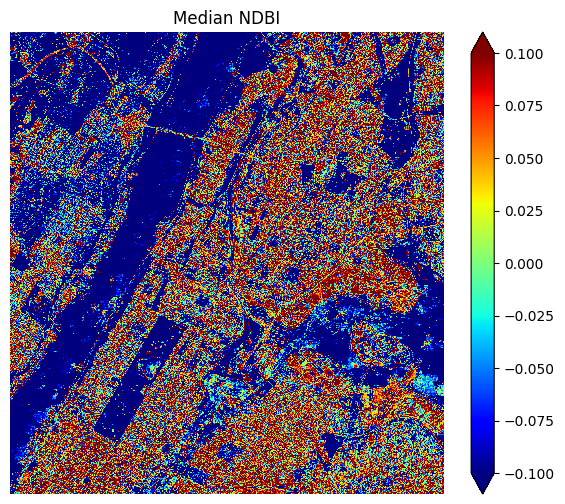

In [25]:
fig, ax = plt.subplots(figsize=(7,6))
ndbi_median.plot.imshow(vmin=-0.1, vmax=0.1, cmap="jet")
plt.title("Median NDBI")
plt.axis('off')
plt.show()

#### Normalized Difference Water Index (NDWI)

The <b>Normalized Difference Water Index (NDWI)</b> is a ratio-based index that uses the Green and Near Infra-Red (NIR) band to highlight areas with surface water. The scale below is set up to highlight areas of water (above zero) in BLUE and areas of non-water (below zero) in RED. Such information can be relevant to modeling urban heating as the proximity to water can mitigate urban heating. The equation uses two spectral bands where: <b>NDWI = (GREEN-NIR) / (GREEN+NIR).

In [26]:
# Calculate NDWI for the median composite
ndwi_median = (median.B03-median.B08)/(median.B03+median.B08)

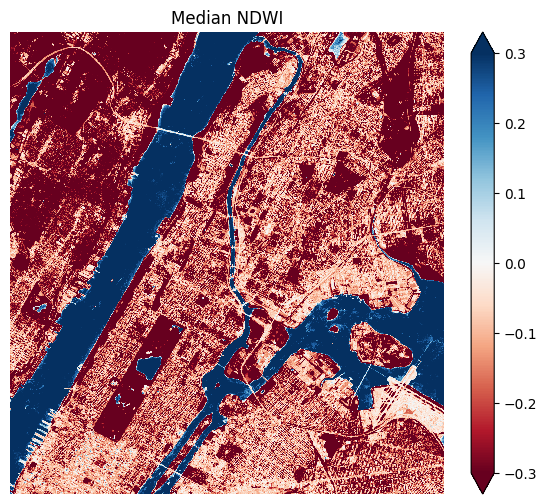

In [27]:
fig, ax = plt.subplots(figsize=(7,6))
ndwi_median.plot.imshow(vmin=-0.3, vmax=0.3, cmap="RdBu")
plt.title("Median NDWI")
plt.axis('off')
plt.show()

#### Shadow Index (SI)

The Shadow Index (SI) is an index used in remote sensing to detect and assess shadowed areas in an image. Shadows are created when objects (e.g., buildings, trees, or terrain) block light, and they often appear darker in satellite or aerial imagery. The Shadow Index helps in identifying areas where shadows occur. The range of the SI typically spans from -1 to +1. Negative values indicate shadows (lower reflectance in both the red and SWIR bands). Positive values indicate illuminated areas or non-shadowed surfaces.

In [28]:
# Calculate SI for the median composite
si_median = (median.B11 - median.B04)/(median.B11 + median.B04)

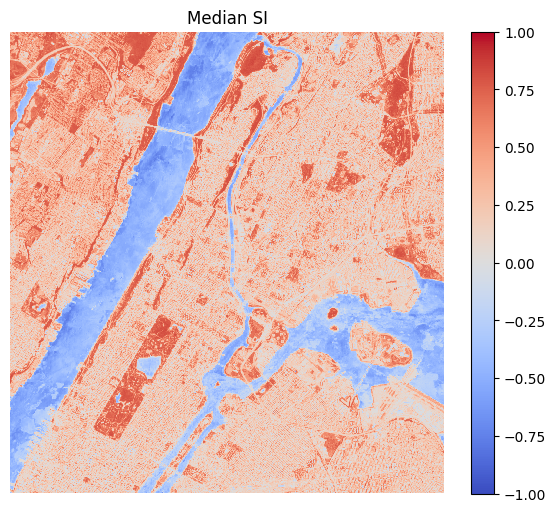

In [29]:
fig, ax = plt.subplots(figsize=(7,6))
si_median.plot.imshow(vmin=-1, vmax=1, cmap="coolwarm")
plt.title("Median SI")
plt.axis('off')
plt.show()

#### Normalized Difference Moisture Index (NDMI)

The normalized difference moisture Index (NDMI) is used to determine vegetation water content and monitor droughts. The value range of the NDMI is -1 to 1. Negative values of NDMI (values approaching -1) correspond to barren soil. Values around zero (-0.2 to 0.4) generally correspond to water stress. High, positive values represent high canopy without water stress (approximately 0.4 to 1).

In [30]:
# Calculate NDMI for the median composite
ndmi_median = (median.B08 - median.B11)/(median.B08 + median.B11)

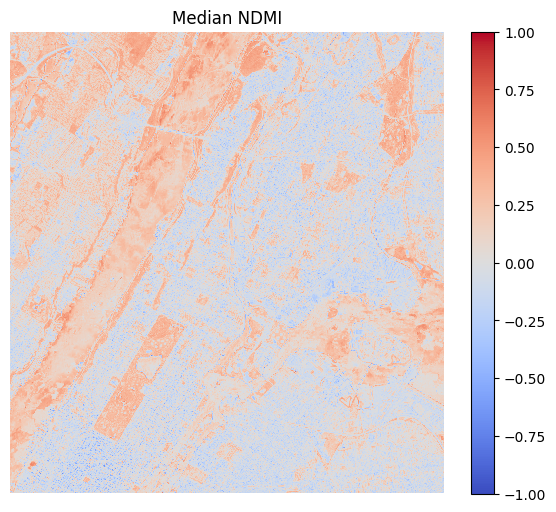

In [31]:
fig, ax = plt.subplots(figsize=(7,6))
ndmi_median.plot.imshow(vmin=-1, vmax=1, cmap="coolwarm")
plt.title("Median NDMI")
plt.axis('off')
plt.show()

#### Normalized Pigment Chlorophyll Ratio Index (NPCRI)

The Normalized Pigment Chlorophyll Ratio Index (NPCRI) is a remote sensing index designed to estimate the chlorophyll content in vegetation. Chlorophyll is a key pigment in plants that is essential for photosynthesis, and its concentration is directly related to plant health and productivity. Being that photosynthesis reduces heat, this might be useful to determine plant productivity in reducing heat. Values close to 1: Indicate high chlorophyll content (healthy vegetation with strong photosynthetic activity).
Values closer to -1: Indicate low chlorophyll content (stressed or unhealthy vegetation).

In [32]:
# Calculate NPCRI for the median composite
npcri_median = (median.B04 - median.B02) / (median.B04 + median.B02)

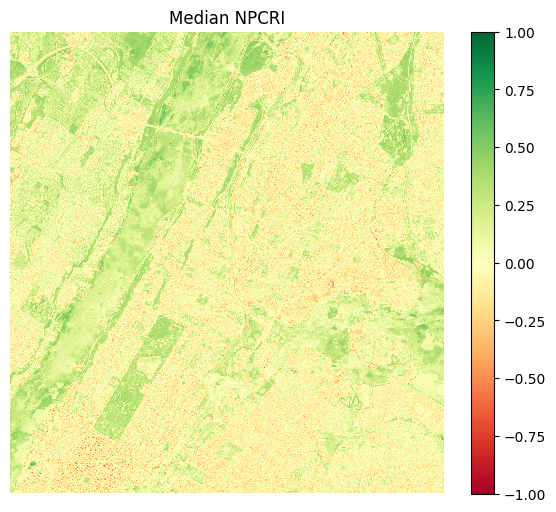

In [33]:
fig, ax = plt.subplots(figsize=(7,6))
ndmi_median.plot.imshow(vmin=-1, vmax=1, cmap="RdYlGn")
plt.title("Median NPCRI")
plt.axis('off')
plt.show()

#### Coastal Aerosol

Coastal aerosol refers to aerosol particles (tiny solid or liquid particles suspended in the atmosphere) that are found in or around coastal regions. These aerosols are typically composed of a variety of substances, including salt, dust, organic compounds, and pollutants. Coastal aerosols have a significant influence on local weather, climate, air quality, and ocean ecosystems.

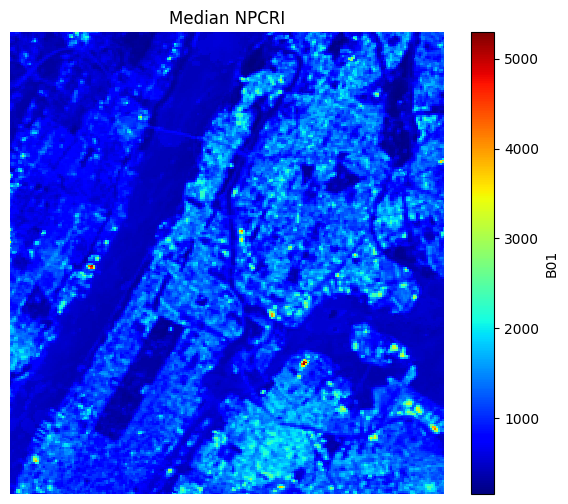

In [34]:
fig, ax = plt.subplots(figsize=(7,6))
median.B01.plot.imshow(cmap="jet")
plt.title("Median NPCRI")
plt.axis('off')
plt.show()

### Add indices to Xarray

In [35]:
# Add indices to the dataset
median['NDVI'] = (['latitude', 'longitude'], ndvi_median.values)
median['NDBI'] = (['latitude', 'longitude'], ndbi_median.values)
median['NDWI'] = (['latitude', 'longitude'], ndwi_median.values)
median['SI'] = (['latitude', 'longitude'], si_median.values)
median['NDMI'] = (['latitude', 'longitude'], ndmi_median.values)
median['NPCRI'] = (['latitude', 'longitude'], npcri_median.values)
median['Coastal_Aerosol'] = (['latitude', 'longitude'], median.B01.values)

In [36]:
median

<xarray.Dataset> Size: 1GB
Dimensions:          (latitude: 2895, longitude: 3340)
Coordinates:
  * latitude         (latitude) float64 23kB 40.88 40.88 40.88 ... 40.75 40.75
  * longitude        (longitude) float64 27kB -74.01 -74.01 ... -73.86 -73.86
    spatial_ref      int32 4B 4326
Data variables: (12/18)
    B01              (latitude, longitude) float64 77MB 705.0 705.0 ... 1.19e+03
    B02              (latitude, longitude) float64 77MB 675.0 ... 1.322e+03
    B03              (latitude, longitude) float64 77MB 820.0 ... 1.446e+03
    B04              (latitude, longitude) float64 77MB 817.0 ... 1.504e+03
    B05              (latitude, longitude) float64 77MB 999.0 ... 1.632e+03
    B06              (latitude, longitude) float64 77MB 2.135e+03 ... 1.722e+03
    ...               ...
    NDBI             (latitude, longitude) float64 77MB -0.02278 ... 0.07312
    NDWI             (latitude, longitude) float64 77MB -0.3939 ... -0.1194
    SI               (latitude, longitude) float64 77MB 0.3761 0.3761 ... 0.1718
    NDMI             (latitude, longitude) float64 77MB 0.02278 ... -0.07312
    NPCRI            (latitude, longitude) float64 77MB 0.09517 ... 0.0644
    Coastal_Aerosol  (latitude, longitude) float64 77MB 705.0 705.0 ... 1.19e+03

### Building Footprints

One way we can use The Building Footprints dataset is to compute a building density metric—for example, the number of buildings, the total building area, or the fraction of a [Buffer Zone](https://atlas.co/glossary/buffer-zones/) covered by buildings.

In [47]:
# Load the Building Footprints (KML)
building_kml_file = "data/Building_Footprint.kml"
buildings_gdf = load_building_footprints(building_kml_file)

We can see the building footprints by plotting it against a satellite image of New York.

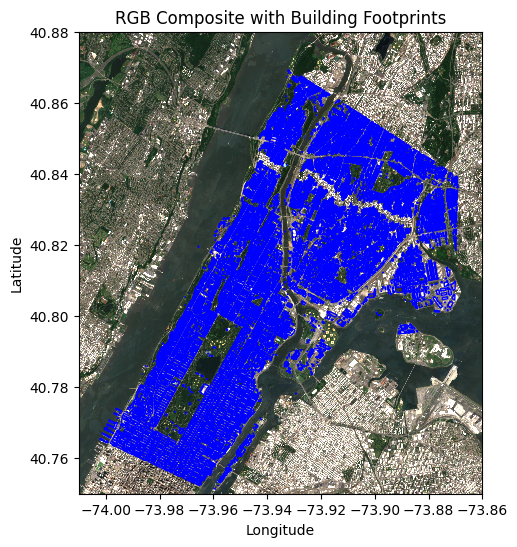

In [53]:
# Create a figure and axis.
fig, ax = plt.subplots(figsize=(7, 6))

# Plot the RGB composite from the median composite.
# This will serve as the base layer.
median[["B04", "B03", "B02"]].to_array().plot.imshow( ax=ax, robust=True, vmin=0, vmax=2500)

# Overlay the building footprints on the same axis.
# building footprints are in EPSG:4326 (lon,lat) so we can plot them directly.
buildings_gdf.plot( ax=ax, edgecolor='blue', facecolor='none')

# Add labels and title.
ax.set_title("RGB Composite with Building Footprints")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

Now, we will add a Buffer Zone to demonstrate that computing a building density metrics (ex; the number of buildings, the total building area, or the fraction of a Buffer Zone covered by buildings) is possible.

First, we will create the buffer zone (more details on how this is done will be in the next section)

In [56]:
# Example point
lat_pt = 40.85880833
lon_pt = -73.932645

# Create a Shapely point
point = Point(lon_pt, lat_pt)

# Define coordinate reference systems (CRS)
crs_wgs84 = pyproj.CRS("EPSG:4326")   # original CRS (degrees)
crs_utm18 = pyproj.CRS("EPSG:32618")    # UTM zone 18N (meters)

# Create transformers to project back and forth
project_to_utm = pyproj.Transformer.from_crs(crs_wgs84, crs_utm18, always_xy=True).transform
project_to_wgs84 = pyproj.Transformer.from_crs(crs_utm18, crs_wgs84, always_xy=True).transform

# Project the point to UTM and create a buffer
point_utm = transform(project_to_utm, point)
buffer_radius = 150 # radius in meters (diameter will be 300)
buffer_utm = point_utm.buffer(buffer_radius)

# Transform the buffer back to WGS84
buffer_wgs84 = transform(project_to_wgs84, buffer_utm)

# The coordinates are one-dimensional arrays for latitude and longitude.
lons = median['NDVI'].coords['longitude'].values
lats = median['NDVI'].coords['latitude'].values

# Create a meshgrid so that each grid cell has a lon/lat pair.
lon_grid, lat_grid = np.meshgrid(lons, lats)

# Use Shapely’s vectorized function to test which grid points fall inside the buffer.
mask = shapely.vectorized.contains(buffer_wgs84, lon_grid, lat_grid)
# 'mask' is a boolean array (True for points inside the buffer)

Next, we will plot the Buffer Zone against The RGB Composite with Building Footprints.

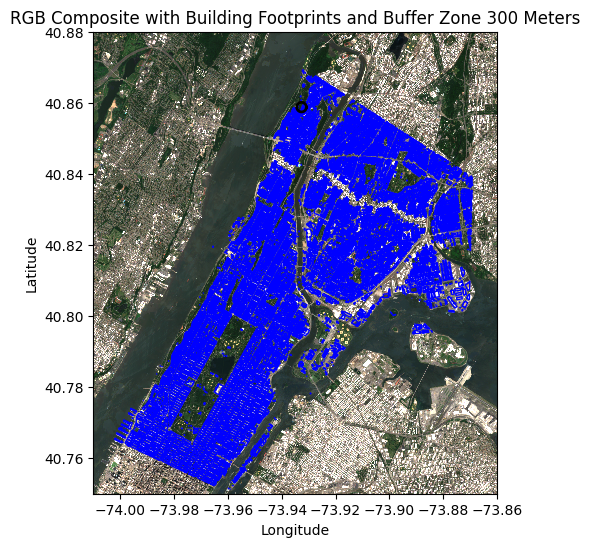

In [57]:
# Create a figure and axis.
fig, ax = plt.subplots(figsize=(7, 6))

# Plot the RGB composite from the median composite.
# This will serve as the base layer.
median[["B04", "B03", "B02"]].to_array().plot.imshow( ax=ax, robust=True, vmin=0, vmax=2500)

# Overlay the building footprints on the same axis.
# building footprints are in EPSG:4326 (lon,lat) so we can plot them directly.
buildings_gdf.plot( ax=ax, edgecolor='blue', facecolor='none')

# Plot the buffer polygon.
# Extract the exterior coordinates of the polygon.
x_buffer, y_buffer = buffer_wgs84.exterior.xy
ax.plot(x_buffer, y_buffer, color='black', linewidth=2, label='Buffer')

# Add labels and title.
ax.set_title("RGB Composite with Building Footprints and Buffer Zone 300 Meters")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

From this plot you can see we can calculate building density metrics in a buffer zone using The Building Footprints dataset.

In [ ]:
# For this example, assume you have:
# - a list of latitudes and longitudes,
# - a list of datetimes,
# - an xarray object 'median' containing your bands (e.g., 'NDVI', 'NDBI', etc.).
latitudes = [40.8588, 40.8600, 40.8550]  # Example latitudes
longitudes = [-73.9326, -73.9350, -73.9300]  # Example longitudes
datetimes = ["2025-01-01", "2025-01-02", "2025-01-03"]

# Specify a buffer radius in meters.
buffer_radius = 1000

# Assume that 'median' has been created from your remote sensing data.
# For example, it might be an xarray Dataset with a band 'NDVI'.
# median = xr.open_dataset("your_dataset.nc")

# Now generate the index dataset.
df_indices = generate_index_dataset(latitudes, longitudes, datetimes, buffer_radius, median, buildings_gdf)
print(df_indices)

### Combating Spacial Autocorrelation While Combining Indices & Building Footprints with Target Variable (UHI Index)

We will create [Buffer Zones](https://atlas.co/glossary/buffer-zones/) to combat [Spacial Autocorrelation](https://www.sciencedirect.com/topics/computer-science/spatial-autocorrelation). Basically, these buffer zones will average features in an area to take into factor all of the feature's measurements in a certain distance. First we will generate a buffer zone of 150 Meters, to see an example of one.

In [37]:
# Example point
lat_pt = 40.85880833
lon_pt = -73.932645

# Create a Shapely point
point = Point(lon_pt, lat_pt)

To create a buffer in meters, we need to project the point to a metric coordinate system. Here we use UTM.

In [38]:
# Define coordinate reference systems (CRS)
crs_wgs84 = pyproj.CRS("EPSG:4326")   # original CRS (degrees)
crs_utm18 = pyproj.CRS("EPSG:32618")    # UTM zone 18N (meters)

# Create transformers to project back and forth
project_to_utm = pyproj.Transformer.from_crs(crs_wgs84, crs_utm18, always_xy=True).transform
project_to_wgs84 = pyproj.Transformer.from_crs(crs_utm18, crs_wgs84, always_xy=True).transform

# Project the point to UTM and create a buffer
point_utm = transform(project_to_utm, point)
buffer_radius = 75  # radius in meters (diameter will be 150)
buffer_utm = point_utm.buffer(buffer_radius)

# Transform the buffer back to WGS84
buffer_wgs84 = transform(project_to_wgs84, buffer_utm)

Now, get the grid of coordinates from our xarray DataArray (median) and create a meshgrid to be able to test which grid points fall inside the buffer using Shapely's vectorized functions.

In [39]:
# The coordinates are one-dimensional arrays for latitude and longitude.
lons = median['NDVI'].coords['longitude'].values
lats = median['NDVI'].coords['latitude'].values

# Create a meshgrid so that each grid cell has a lon/lat pair.
lon_grid, lat_grid = np.meshgrid(lons, lats)  # both arrays will have shape (2895, 3340)

# Use Shapely’s vectorized function to test which grid points fall inside the buffer.
mask = shapely.vectorized.contains(buffer_wgs84, lon_grid, lat_grid)
# 'mask' is a boolean array (True for points inside the buffer)

# Get the indices or coordinates of the points inside the buffer
indices_inside = np.where(mask)
lat_inside = lat_grid[indices_inside]
lon_inside = lon_grid[indices_inside]
ndvi_inside = median['NDVI'].values[indices_inside]

print("Number of grid cells inside the buffer:", mask.sum())

Number of grid cells inside the buffer: 927


Finally, we will plot the buffer, the points inside the buffer, and the rest of the map.

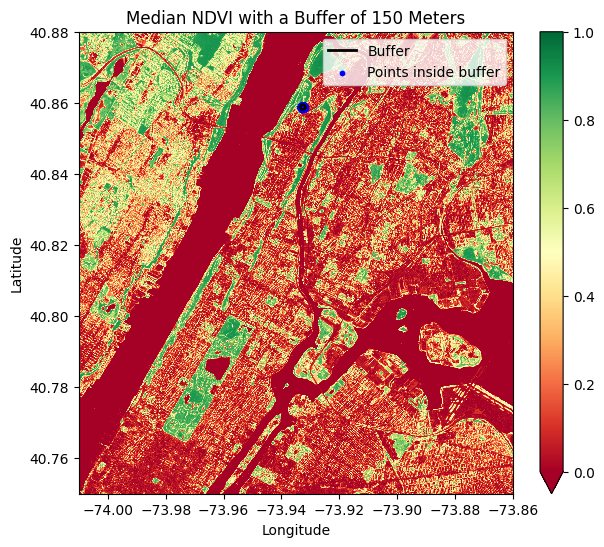

In [40]:
# Plotting
fig, ax = plt.subplots(figsize=(7, 6))

# Plot the NDVI data.
ndvi_median.plot.imshow(vmin=0.0, vmax=1.0, cmap="RdYlGn")

# Plot the buffer polygon.
# Extract the exterior coordinates of the polygon.
x_buffer, y_buffer = buffer_wgs84.exterior.xy
ax.plot(x_buffer, y_buffer, color='black', linewidth=2, label='Buffer')

# Plot the grid points that fall inside the buffer.
ax.scatter(lon_inside, lat_inside, s=10, color='blue', label='Points inside buffer')

# Add labels and title.
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Median NDVI with a Buffer of 150 Meters')
ax.legend()

plt.show()

To combat spacial autocorrelation we will create different bufferzones with different radiuses to see which will perform better. We want bufferzones of approximately 50 meters, 100 meters, and 150 meters.


In [39]:
#csv path for target variable
csv_path = "data/Training_data_uhi_index.csv"

# Read the Excel file using pandas
uhi_df = pd.read_csv(csv_path)
# uhi = uhi_df['UHI Index'].values TODO: uncomment and remove sample
# latitudes = uhi_df['Latitude'].values
# longitudes = uhi_df['Longitude'].values
# datetimes = uhi_df['datetime'].values

# Grab 20% of the data (For testing the buffer function)
sampled_df = uhi_df.sample(frac=0.05, random_state=42)

# Extract the values
uhi = sampled_df['UHI Index'].values
latitudes = sampled_df['Latitude'].values
longitudes = sampled_df['Longitude'].values
datetimes = sampled_df['datetime'].values

#### 50 Meters

In [40]:
buffer_radius = 25  # radius in meters (diameter will be 50)

index_50m_df = generate_index_dataset(latitudes, longitudes, uhi, datetimes, buffer_radius, median)


Extracting average values: 100%|██████████| 561/561 [14:58<00:00,  1.60s/it]


In [41]:
index_50m_df.describe()

,Longitude,Latitude,UHI,NDVI,NDBI,NDWI,SI,NDMI,NPCRI,Coastal_Aerosol
count,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000
mean,-73.932898,40.809351,0.999866,0.217801,0.011612,-0.236813,0.242288,-0.011612,0.079215,1144.737374
std,0.027726,0.024028,0.016517,0.179703,0.101422,0.150589,0.117921,0.101422,0.028719,339.480390
min,-73.994068,40.759105,0.956122,0.005262,-0.321934,-0.760657,0.026666,-0.193091,-0.092243,302.352381
25%,-73.955153,40.788963,0.989419,0.089954,-0.025874,-0.296420,0.170393,-0.081580,0.069569,964.009615
50%,-73.931807,40.811732,0.999877,0.158742,0.038969,-0.190914,0.213069,-0.038969,0.082467,1145.548077
75%,-73.909253,40.826273,1.011417,0.282793,0.081580,-0.131927,0.275400,0.025874,0.094357,1348.153846
max,-73.879912,40.859440,1.040386,0.829588,0.193091,-0.038589,0.703964,0.321934,0.223528,2307.821782


#### 100 Meters

In [ ]:
buffer_radius = 50  # radius in meters (diameter will be 100)

index_100m_df = generate_index_dataset(latitudes, longitudes, uhi, datetimes, buffer_radius, median)

In [44]:
index_100m_df.describe()

NameError: name 'index_100m_df' is not defined

#### 150 Meters

In [ ]:
buffer_radius = 75  # radius in meters (diameter will be 150)

index_150m_df = generate_index_dataset(latitudes, longitudes, uhi, datetimes, buffer_radius, median)

In [ ]:
index_150m_df.describe()

### NY Mesonet Weather

To add the New york Mesonet Weather to our dataset we will need to figure out the closest weather station (Bronx or Manhattan) to our latitudes and longitudes. Then locate the weather for the time UHI was collected.

- The **Bronx** weather station is at (lat=40.87248, long=-73.89352)
- The **Manhattan** weather station is at (lat=40.76754, long=-73.96449)

![NY Weather Stations](https://github.com/FranciscoLozCoding/cooling_with_code/blob/main/images/NY_weather_stations.jpeg?raw=1)
>The image above shows the location of the weather stations that collected the "NY Mesonet Weather" dataset.

In [48]:
# Read the weather data for both counties
weather_manhattan = pd.read_csv('data/NY_Mesonet_Weather_Manhattan.csv')
weather_bronx = pd.read_csv('data/NY_Mesonet_Weather_Bronx.csv')

# Convert the "Date / Time" column to datetime
weather_manhattan['Date / Time'] = pd.to_datetime(weather_manhattan['Date / Time'])
weather_bronx['Date / Time'] = pd.to_datetime(weather_bronx['Date / Time'])

#### Locate Closest Weather Station

Apple the "Closest Weather Station" functions we created to each of the Dataframes.

In [65]:

index_50m_df[['Air Temp at Surface [degC]',
        'Relative Humidity [percent]',
        'Avg Wind Speed [m/s]',
        'Wind Direction [degrees]',
        'Solar Flux [W/m^2]']] = index_50m_df.apply(lambda row: assign_weather_data(row, weather_manhattan, weather_bronx), axis=1)

In [ ]:
index_50m_df.describe()

In [ ]:
index_100m_df[['Air Temp at Surface [degC]',
        'Relative Humidity [percent]',
        'Avg Wind Speed [m/s]',
        'Wind Direction [degrees]',
        'Solar Flux [W/m^2]']] = index_100m_df.apply(lambda row: assign_weather_data(row, weather_manhattan, weather_bronx), axis=1)

In [ ]:
index_100m_df.describe()

In [ ]:
index_150m_df[['Air Temp at Surface [degC]',
        'Relative Humidity [percent]',
        'Avg Wind Speed [m/s]',
        'Wind Direction [degrees]',
        'Solar Flux [W/m^2]']] = index_150m_df.apply(lambda row: assign_weather_data(row, weather_manhattan, weather_bronx), axis=1)

In [ ]:
index_150m_df.describe()

### Removing Columns We Can't Use

TODO: remove the lat and lon columns

## Reference

- Description: Ground temperature data over New York City on July 24, 2021 (CSV format)
Contributors: Climate, Adaptation, Planning, Analytics (CAPA) Strategies
Data Host: Center for Open Science - https://www.cos.io
Terms of Use: https://github.com/CenterForOpenScience/cos.io/blob/master/TERMS_OF_USE.md
License: Apache 2.0 > https://github.com/CenterForOpenScience/cos.io/blob/master/LICENSE
Satellite Data (Sentinel-2 Sample Output)

- Description: Copernicus Sentinel-2 sample data from 2021 obtained from the Microsoft Planetary Computer (TIFF format)
Contributors: European Space Agency (ESA), Microsoft
Data Host: Microsoft Planetary Computer - https://planetarycomputer.microsoft.com/dataset/sentinel-2-l2a
Terms of Use: https://sentinel.esa.int/documents/247904/690755/Sentinel_Data_Legal_Notice
License: https://creativecommons.org/licenses/by-sa/3.0/igo/
Building Footprint Data

- Description: Building footprint polygons over the data challenge region of interest (KML format)
Contributors: Open Data Team at the NYC Office of Technology and Innovation (OTI) - New York City Open Data Project
Data Host: https://data.cityofnewyork.us/Housing-Development/Building-Footprints/nqwf-w8eh
Terms of Use: https://www.nyc.gov/html/data/terms.html and https://www.nyc.gov/home/terms-of-use.page
License: https://github.com/CityOfNewYork/nyc-geo-metadata#Apache-2.0-1-ov-file
Weather Data

- Description: Detailed weather data collected every 5 minutes at two locations (Bronx and Manhattan). Includes surface air temperature (2-meters), relative humidity, average wind speed, wind direction, and solar flux.
Contributors: Contributors: New York State Mesonet
Data Host: https://nysmesonet.org/
Terms of Use: https://nysmesonet.org/about/data
License: https://nysmesonet.org/documents/NYS_Mesonet_Data_Access_Policy.pdf